# **Early Sepsis Detection from ICU Clinical Data**

## **Internship Project**

### **Created by**: Maira Asim

---

## **Project Overview**

This project focuses on predicting the risk of sepsis using ICU clinical data.

Sepsis is a serious medical condition that can become life-threatening if not detected early. In this project, machine learning models are used to analyze patient clinical features and predict whether a patient may be at risk of sepsis.

## Objective

The objective of this project is to build a machine learning model that can classify patients as:

- Sepsis Risk
- No Sepsis Risk

## Planned Workflow

1. Import required libraries
2. Load the sepsis dataset
3. Understand the dataset
4. Check missing values
5. Perform exploratory data analysis
6. Preprocess the data
7. Handle class imbalance
8. Train machine learning models
9. Compare model performance
10. Evaluate the best model
11. Create visualizations
12. Save results
13. Document the project on GitHub

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Class imbalance handling
from imblearn.over_sampling import SMOTE

# Save model
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("../data/Sepsis_def.csv")
df.head()

,cod,Fecha_ing,Sexo,Edad,Hospital,Proced,Reg_salud,Peso,Talla,IMC,...,SOFA,ATB_1,ATB_2,ATB_3,Cultivos,IOT,Dias_iot,IRA,Dialisis,Muerte
0,57,09/11/2021,0,48,0,2,1,78.0,1.66,28.3,...,16,4,17,17,1,1,4,1,0,0
1,88,18/03/2022,1,66,1,4,1,70.0,1.57,28.4,...,9,0,17,17,0,0,0,0,0,0
2,37,11/08/2021,0,74,0,2,1,59.0,1.62,22.5,...,14,17,17,17,8,0,0,0,0,0
3,198,28/08/2022,0,83,1,4,1,73.0,1.62,27.8,...,8,7,13,17,9,0,0,1,0,0
4,152,13/05/2022,1,78,1,3,0,65.1,1.64,24.2,...,9,0,17,17,0,0,0,0,0,0


## **Dataset Overview**

The dataset has been loaded successfully using Pandas.

It contains clinical and hospital-related patient features such as age, sex, BMI, SOFA score, antibiotic information, cultures, ICU-related variables, dialysis, and mortality status.

The target column appears to be `Muerte`, which represents patient mortality outcome.

In [5]:
# Check dataset size
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Show all column names
df.columns

Number of rows: 200
Number of columns: 97


Index(['cod', 'Fecha_ing', 'Sexo', 'Edad', 'Hospital', 'Proced', 'Reg_salud',
       'Peso', 'Talla', 'IMC', 'HTA', 'ARA_2', 'IECA', 'Tiazidas', 'diur_asa',
       'Calcio antagonista', 'Beta_bloqueador', 'Otros_antihta', 'DM_2',
       'Metformina', 'iSGLT2', 'DDPIV', 'GLP1a', 'Insulina_basal',
       'Dosis_basal', 'Insulina_preprandial', 'Dosis_preprandial',
       'Otros_antidiabeticos', 'Hipotiroidismo', 'ERC', 'Tabaco',
       'Enf_coronaria', 'Obesidad', 'Dislipidemia', 'ACV', 'Fib_aur',
       'Autoinmune', 'Sepsis', 'Alt_C', 'Tas_inicial', 'Tad_inicial',
       'Tam_inicial', 'Fc_inicial', 's_index0', 'fctad_inicial', 'Fr_inicial',
       'Tas_12h', 'Tad_12h', 'Tam_12h', 'Fc_12h', 's_index12', 'fctad_12h',
       'Tas_24h', 'Tad_24h', 'Tam_24h', 'Fc_24h', 's_index24', 'fctad_24h',
       'Sato2_inicial', 'Lactato_inicial', 'Lactato_24h', 'capilar',
       'capilar24', 'ph', 'pH24', 'Hco3', 'Hco3_24', 'Wbc_inicial',
       'N_inicial', 'L_inicial', 'NL', 'Wbc_24h', 'N_24h', 'L_

## **Target Variable Check**

In this step, the target variable is checked.

The column `Sepsis` is selected as the target variable because the project aims to predict whether a patient is at risk of sepsis or not.

The column `Muerte` represents mortality outcome, so it will not be used as an input feature for sepsis prediction.

In [7]:
# Check values in target column
print("Sepsis value counts:")
print(df["Sepsis"].value_counts())

Sepsis value counts:
Sepsis
10    53
7     53
0     33
8     15
1     10
9      8
3      8
4      7
6      6
5      5
2      2
Name: count, dtype: int64


## **Check Missing Values**

In this step, missing values in the dataset are checked.

Medical datasets often contain missing values because not every test or clinical measurement is recorded for every patient.

Checking missing values helps us decide how to clean and preprocess the data before training machine learning models.

In [9]:
df.isnull().sum()

cod          0
Fecha_ing    0
Sexo         0
Edad         0
Hospital     0
            ..
IOT          0
Dias_iot     0
IRA          0
Dialisis     0
Muerte       0
Length: 97, dtype: int64

In [10]:
print("Total missing values in dataset:", df.isnull().sum().sum())

Total missing values in dataset: 0


## **Create Binary Target Variable**

The original `Sepsis` column contains multiple values from 0 to 10.

To make this project suitable for disease risk prediction, the target is converted into a binary variable:

- `0` = No Sepsis Risk
- `1` = Sepsis Risk

If the original `Sepsis` value is `0`, it is treated as no sepsis risk.  
If the original `Sepsis` value is greater than `0`, it is treated as sepsis risk.

In [11]:
# Create binary target column
df["Sepsis_Risk"] = df["Sepsis"].apply(lambda x: 0 if x == 0 else 1)

# Check new target distribution
print("Sepsis Risk value counts:")
print(df["Sepsis_Risk"].value_counts())

print("\nSepsis Risk percentage distribution:")
print(df["Sepsis_Risk"].value_counts(normalize=True) * 100)

Sepsis Risk value counts:
Sepsis_Risk
1    167
0     33
Name: count, dtype: int64

Sepsis Risk percentage distribution:
Sepsis_Risk
1    83.5
0    16.5
Name: proportion, dtype: float64


### **Target Variable Observation**

- A new binary target column named `Sepsis_Risk` was created.
- `0` represents No Sepsis Risk.
- `1` represents Sepsis Risk.
- The dataset contains **167 sepsis-risk cases** and **33 no-sepsis-risk cases**.
- This means the dataset is imbalanced because the sepsis-risk class is much larger.
- Class imbalance will be handled later before training the machine learning models.

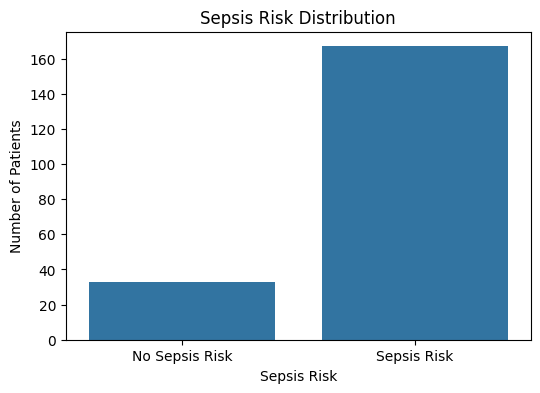

In [12]:
# Visualize target distribution
plt.figure(figsize=(6, 4))

sns.countplot(x="Sepsis_Risk", data=df)

plt.title("Sepsis Risk Distribution")
plt.xlabel("Sepsis Risk")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Sepsis Risk", "Sepsis Risk"])

plt.show()

## **Check Data Types**

In this step, the data types of all columns are checked.

Machine learning models work with numerical data, so non-numeric columns such as dates need to be handled before training.

In [13]:
# Check data types of all columns
df.dtypes

cod             int64
Fecha_ing      object
Sexo            int64
Edad            int64
Hospital        int64
                ...  
Dias_iot        int64
IRA             int64
Dialisis        int64
Muerte          int64
Sepsis_Risk     int64
Length: 98, dtype: object

In [14]:
# Check non-numeric columns
non_numeric_columns = df.select_dtypes(include=["object"]).columns

print("Non-numeric columns:")
print(non_numeric_columns.tolist())

Non-numeric columns:
['Fecha_ing']


## **Handle Non-Numeric Columns**

Machine learning models require numerical input.

The column `Fecha_ing` contains date values, so it will not be used directly for model training in this project.

In [15]:
# Drop non-useful columns
df_clean = df.drop(columns=["Fecha_ing", "cod"])

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

Original dataset shape: (200, 98)
Cleaned dataset shape: (200, 96)


### **Non-Numeric Column Observation**

- The dataset had one non-numeric column: `Fecha_ing`.
- `Fecha_ing` contains date values and was removed for this version of the project.
- The column `cod` was also removed because it is only a patient/code identifier and does not provide useful medical information for prediction.
- After removing these columns, the cleaned dataset shape became `(200, 96)`.

## **Separate Features and Target**

In this step, the dataset is divided into input features and the target variable.

- `X` contains the patient clinical features used for prediction.
- `y` contains the target variable `Sepsis_Risk`.

The original `Sepsis` column and `Muerte` column are removed from the input features to avoid data leakage.

In [16]:
# Separate features and target
X = df_clean.drop(columns=["Sepsis_Risk", "Sepsis", "Muerte"])
y = df_clean["Sepsis_Risk"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

Feature data shape: (200, 93)
Target data shape: (200,)


### **Feature and Target Separation Observation**

- The dataset was divided into input features `X` and target variable `y`.
- `X` contains **93 clinical features** that will be used for prediction.
- `y` contains the target column `Sepsis_Risk`.
- The target variable has **200 values**, one for each patient.

### **Why Some Columns Were Removed**

Some columns were removed from the input features to avoid incorrect model learning and data leakage.

- `Sepsis_Risk` was removed because it is the final target variable that the model has to predict.
- `Sepsis` was removed because it was used to create the `Sepsis_Risk` target column. Keeping it would make the prediction too easy and unrealistic.
- `Muerte` was removed because it represents patient mortality outcome. Mortality happens after the clinical condition and should not be used as an input feature for predicting sepsis risk.

Removing these columns helps make the model more realistic and prevents data leakage.

---
## **Train-Test Split**

The dataset is divided into training and testing sets.

- Training data is used to teach the machine learning models.
- Testing data is used to evaluate how well the models perform on unseen patient data.

A stratified split is used so that both training and testing sets keep a similar proportion of sepsis-risk and no-sepsis-risk cases.

In [17]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (160, 93)
X_test shape: (40, 93)
y_train shape: (160,)
y_test shape: (40,)

Training target distribution:
Sepsis_Risk
1    134
0     26
Name: count, dtype: int64

Testing target distribution:
Sepsis_Risk
1    33
0     7
Name: count, dtype: int64


### **Train-Test Split Observation**

- The dataset was split into training and testing sets.
- 80% of the data was used for training and 20% was used for testing.
- The training set contains **160 patients** and the testing set contains **40 patients**.
- Each patient has **93 input features**.
- Stratified splitting was used, so both training and testing sets have a similar class distribution.
- The dataset is still imbalanced, with more sepsis-risk cases than no-sepsis-risk cases.

## **Feature Scaling**

Feature scaling is applied to make all numerical features have a similar scale.

This is important because some machine learning models, such as Logistic Regression and SVM, are sensitive to feature ranges.

StandardScaler is used to transform the data so that features have a mean close to 0 and a standard deviation close to 1.

In [18]:
# Apply feature scaling
scaler = StandardScaler()

# Fit scaler on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (160, 93)
Scaled testing data shape: (40, 93)


## **Handle Class Imbalance Using SMOTE**

The dataset is imbalanced because the number of sepsis-risk cases is much higher than no-sepsis-risk cases.

To handle this, SMOTE is applied to the training data.

SMOTE creates synthetic samples for the minority class so that the model can learn both classes more fairly.

SMOTE is applied only on the training data to avoid data leakage.

In [19]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

print("\nBalanced training data shape:", X_train_balanced.shape)

Before SMOTE:
Sepsis_Risk
1    134
0     26
Name: count, dtype: int64

After SMOTE:
Sepsis_Risk
1    134
0    134
Name: count, dtype: int64

Balanced training data shape: (268, 93)
